# LAB DAY 19 — Xây dựng hệ thống **GraphRAG** với Tech Company Corpus

**Sinh viên:** Nguyễn Đức Kiên Trung &nbsp;•&nbsp; **MSSV:** 2A202600769 &nbsp;•&nbsp; **Ngày:** 2026-06-23

Notebook này xây dựng một pipeline **GraphRAG** hoàn chỉnh và so sánh với **Flat RAG**.
Toàn bộ chạy **offline / miễn phí** bằng stack cục bộ:

| Thành phần | Công cụ |
|---|---|
| LLM (trích xuất + sinh câu trả lời) | **Ollama** · `qwen2.5:3b` |
| Embeddings (Flat RAG) | `sentence-transformers · all-MiniLM-L6-v2` |
| Vector DB (Flat RAG) | **FAISS** |
| Đồ thị tri thức (GraphRAG) | **NetworkX** (MultiDiGraph) |
| Trực quan hóa | **Matplotlib** |

### Mục tiêu
1. Trích xuất thực thể (Entity) & quan hệ (Relation) từ văn bản thô → **Triples**.
2. Dựng **Knowledge Graph** bằng NetworkX (có khử trùng lặp).
3. Truy vấn **đa bước (2-hop)**: entity linking → BFS → textualization → LLM.
4. So sánh độ chính xác **Flat RAG vs GraphRAG** trên 20 câu hỏi benchmark + phân tích chi phí.


## Phần 1 — Nghiên cứu (Research)

**1. Entity Extraction — LLM phân biệt thực thể (Node) và thuộc tính (Property) thế nào?**
LLM dựa vào vai trò ngữ nghĩa trong câu. *Thực thể* là đối tượng có danh tính riêng, có thể được
tham chiếu lại và đứng làm chủ/tân ngữ của nhiều quan hệ (công ty, người, sản phẩm) → trở thành **Node**.
*Thuộc tính* là giá trị mô tả gắn liền một thực thể, thường không có quan hệ riêng (năm thành lập, thành phố) →
gắn vào node dưới dạng **edge tới một literal** hoặc property. Trong lab này ta mô hình hoá mọi thứ thành
triple `(subject, PREDICATE, object)`; những giá trị như năm `2015` là object literal của quan hệ `FOUNDED_IN`.

**2. Graph Construction — Vì sao khử trùng lặp (Deduplication) lại quan trọng?**
LLM tạo ra nhiều biến thể bề mặt cho cùng một thực thể: *"Google"*, *"Google LLC"*, *"the company"*.
Nếu không hợp nhất, đồ thị bị **phân mảnh**: các sự kiện về cùng một thực thể nằm rải ở nhiều node khác nhau,
khiến việc duyệt đa bước **đứt gãy** (không tìm được đường đi) và làm phình số node vô nghĩa.
Khử trùng lặp (chuẩn hóa tên + gộp alias) đảm bảo **một thực thể = một node**, giữ cho các chuỗi quan hệ liền mạch.

**3. Query Answering — Khác biệt giữa duyệt đồ thị (BFS) và tìm kiếm vector?**
*Vector search (Flat RAG)* trả về các đoạn văn **tương tự bề mặt** với câu hỏi; nó **không có khái niệm liên kết**
giữa các sự kiện, nên với câu hỏi đa bước ("Ai sáng lập công ty mà Google mua năm 2014?") nó thường lấy nhầm đoạn
và **bịa (hallucinate)**. *BFS trên đồ thị (GraphRAG)* đi theo **quan hệ tường minh**: từ node `Google` → cạnh
`ACQUIRED` → `DeepMind` → cạnh `FOUNDED_BY` → `Demis Hassabis`. Nó **lần theo cấu trúc tri thức** thay vì độ tương tự,
nên giải được suy luận nhiều bước.


## Phần 2 — Environment Setup

Cài đặt (chỉ chạy 1 lần). Lab dùng Ollama cục bộ thay cho OpenAI để **miễn phí & offline**:

```bash
pip install networkx matplotlib neo4j openai pandas
pip install langchain langchain-openai faiss-cpu sentence-transformers
# LLM cục bộ:  https://ollama.com  ->  ollama pull qwen2.5:3b
```
> `USE_TF=0` được set trước khi import `sentence-transformers` để tránh xung đột TensorFlow/Keras-3.


In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json, re, time, urllib.request
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
print("Imports OK")

Imports OK


## Bộ dữ liệu — *Tech Company Corpus*

42 câu sự kiện về các công ty công nghệ. Nhiều sự kiện được **móc xích** qua nhiều câu
(vd: *DeepMind → sáng lập bởi Demis Hassabis*; *DeepMind → bị Google mua lại*) — đây chính là phần
GraphRAG duyệt được còn Flat RAG hay bỏ sót.

In [2]:
CORPUS = [
    # OpenAI cluster
    "OpenAI was founded by Sam Altman and Elon Musk in 2015.",
    "OpenAI is headquartered in San Francisco.",
    "OpenAI created the ChatGPT product.",
    "OpenAI developed the GPT-4 model.",
    "Microsoft invested in OpenAI in 2019.",
    "Sam Altman is the CEO of OpenAI.",

    # Google / Alphabet / DeepMind cluster
    "Google was founded by Larry Page and Sergey Brin in 1998.",
    "Google is headquartered in Mountain View.",
    "Alphabet is the parent company of Google.",
    "Sundar Pichai is the CEO of Google.",
    "Google acquired DeepMind in 2014.",
    "DeepMind was founded by Demis Hassabis in 2010.",
    "DeepMind is headquartered in London.",
    "DeepMind developed the AlphaGo program.",
    "Google acquired YouTube in 2006.",
    "YouTube was founded by Steve Chen and Chad Hurley in 2005.",
    "Google developed the TensorFlow framework.",
    "Google developed the Gemini model.",

    # Microsoft cluster
    "Microsoft was founded by Bill Gates and Paul Allen in 1975.",
    "Microsoft is headquartered in Redmond.",
    "Satya Nadella is the CEO of Microsoft.",
    "Microsoft acquired GitHub in 2018.",
    "Microsoft acquired LinkedIn in 2016.",
    "GitHub was founded by Tom Preston-Werner in 2008.",
    "Microsoft developed the Windows operating system.",

    # Meta cluster
    "Meta was founded by Mark Zuckerberg in 2004.",
    "Meta is headquartered in Menlo Park.",
    "Meta acquired Instagram in 2012.",
    "Meta acquired WhatsApp in 2014.",
    "Instagram was founded by Kevin Systrom in 2010.",
    "WhatsApp was founded by Jan Koum in 2009.",
    "Meta developed the LLaMA model.",

    # Nvidia / Tesla / SpaceX / Anthropic / Apple cluster
    "Nvidia was founded by Jensen Huang in 1993.",
    "Nvidia is headquartered in Santa Clara.",
    "Nvidia developed the CUDA platform.",
    "Tesla was founded by Elon Musk in 2003.",
    "Tesla is headquartered in Austin.",
    "SpaceX was founded by Elon Musk in 2002.",
    "Anthropic was founded by Dario Amodei in 2021.",
    "Anthropic developed the Claude model.",
    "Amazon invested in Anthropic in 2023.",
    "Apple was founded by Steve Jobs and Steve Wozniak in 1976.",
    "Tim Cook is the CEO of Apple.",
    "Apple is headquartered in Cupertino.",
]

# Benchmark questions. `hop` flags whether answering needs to combine facts
# from MORE THAN ONE sentence (the multi-hop / GraphRAG-favouring cases).
BENCHMARK = [
    # ---- single-hop (both systems should get these) ----
    {"q": "Who founded OpenAI?", "ref": "Sam Altman and Elon Musk", "hop": 1},
    {"q": "Where is DeepMind headquartered?", "ref": "London", "hop": 1},
    {"q": "Who is the CEO of Microsoft?", "ref": "Satya Nadella", "hop": 1},
    {"q": "In what year was Instagram founded?", "ref": "2010", "hop": 1},
    {"q": "Which company did Google acquire in 2006?", "ref": "YouTube", "hop": 1},
    {"q": "Who founded Nvidia?", "ref": "Jensen Huang", "hop": 1},
    {"q": "What model did Anthropic develop?", "ref": "Claude", "hop": 1},

    # ---- multi-hop (combine 2+ facts; Flat RAG tends to miss / hallucinate) ----
    {"q": "Who founded the company that Google acquired in 2014?",
     "ref": "Demis Hassabis (founder of DeepMind)", "hop": 2},
    {"q": "Which company acquired the company that developed AlphaGo?",
     "ref": "Google (acquired DeepMind)", "hop": 2},
    {"q": "Who founded the company that created ChatGPT?",
     "ref": "Sam Altman and Elon Musk", "hop": 2},
    {"q": "Which big company invested in the maker of GPT-4?",
     "ref": "Microsoft", "hop": 2},
    {"q": "Who is the CEO of the parent company's subsidiary that acquired YouTube?",
     "ref": "Sundar Pichai (CEO of Google)", "hop": 3},
    {"q": "Which company founded by Mark Zuckerberg acquired WhatsApp?",
     "ref": "Meta", "hop": 2},
    {"q": "Who founded the photo-sharing app that Meta acquired in 2012?",
     "ref": "Kevin Systrom (founder of Instagram)", "hop": 2},
    {"q": "Which code-hosting company that Microsoft acquired was founded by Tom Preston-Werner?",
     "ref": "GitHub", "hop": 2},
    {"q": "Elon Musk co-founded OpenAI; which car company did he also found?",
     "ref": "Tesla", "hop": 2},
    {"q": "Which company invested in the maker of the Claude model?",
     "ref": "Amazon (invested in Anthropic)", "hop": 2},
    {"q": "Who founded the company headquartered in London that Google owns?",
     "ref": "Demis Hassabis (DeepMind)", "hop": 2},
    {"q": "Name a founder shared by OpenAI, Tesla, and SpaceX.",
     "ref": "Elon Musk", "hop": 3},
    {"q": "Which company developed the model named Gemini and who is its CEO?",
     "ref": "Google, CEO Sundar Pichai", "hop": 2},
]


In [3]:
print(f"Corpus: {len(CORPUS)} câu | Benchmark: {len(BENCHMARK)} câu hỏi")
for d in CORPUS[:5]:
    print(" •", d)

Corpus: 44 câu | Benchmark: 20 câu hỏi
 • OpenAI was founded by Sam Altman and Elon Musk in 2015.
 • OpenAI is headquartered in San Francisco.
 • OpenAI created the ChatGPT product.
 • OpenAI developed the GPT-4 model.
 • Microsoft invested in OpenAI in 2019.


## Thư viện lõi GraphRAG

Toàn bộ logic (gọi Ollama + đếm token, trích xuất triple, dựng đồ thị có khử trùng lặp,
truy vấn 2-hop, và baseline Flat RAG) gói trong một cell để notebook **độc lập**.

In [4]:
import os
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_TORCH", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import json
import re
import time
import urllib.request
from collections import defaultdict

OLLAMA_URL = "http://localhost:11434/api"
LLM_MODEL = "qwen2.5:3b"

# ---------------------------------------------------------------------------
# Token accounting -- lets us report real token usage / latency (deliverable 4)
# ---------------------------------------------------------------------------
STATS = {"calls": 0, "prompt_tokens": 0, "completion_tokens": 0, "seconds": 0.0}


def reset_stats():
    for k in STATS:
        STATS[k] = 0 if k != "seconds" else 0.0


def ollama_generate(prompt, system=None, temperature=0.0, num_predict=512, fmt=None):
    """Single-turn completion via Ollama; records token + latency stats."""
    payload = {
        "model": LLM_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature, "num_predict": num_predict},
    }
    if system:
        payload["system"] = system
    if fmt:
        payload["format"] = fmt  # e.g. "json" -> constrained JSON output
    data = json.dumps(payload).encode()
    req = urllib.request.Request(
        OLLAMA_URL + "/generate", data=data, headers={"Content-Type": "application/json"}
    )
    t = time.time()
    resp = json.loads(urllib.request.urlopen(req, timeout=300).read())
    STATS["calls"] += 1
    STATS["seconds"] += time.time() - t
    STATS["prompt_tokens"] += resp.get("prompt_eval_count", 0)
    STATS["completion_tokens"] += resp.get("eval_count", 0)
    return resp.get("response", "")


# ---------------------------------------------------------------------------
# Step 1 -- Entity & Relation extraction (Indexing)
# ---------------------------------------------------------------------------
EXTRACT_SYSTEM = (
    "You are a precise information extraction engine. "
    "From the text you output a knowledge graph as SUBJECT-PREDICATE-OBJECT triples. "
    "A SUBJECT/OBJECT is a named entity (company, person, product, place) or a literal "
    "value such as a year. The PREDICATE is an UPPER_SNAKE_CASE relation. "
    "Return ONLY JSON of the form {\"triples\": [[\"subject\",\"PREDICATE\",\"object\"], ...]}. "
    "Use canonical entity names (e.g. 'Google' not 'the company'). Do not invent facts."
)

EXTRACT_FEWSHOT = (
    'Text: "OpenAI was founded by Sam Altman and Elon Musk in 2015. It created ChatGPT."\n'
    'JSON: {"triples": [["OpenAI","FOUNDED_BY","Sam Altman"],'
    '["OpenAI","FOUNDED_BY","Elon Musk"],["OpenAI","FOUNDED_IN","2015"],'
    '["OpenAI","CREATED","ChatGPT"]]}'
)


def extract_triples(text):
    """LLM -> list of (subj, pred, obj) triples for one document."""
    prompt = f"{EXTRACT_FEWSHOT}\n\nText: \"{text}\"\nJSON:"
    raw = ollama_generate(prompt, system=EXTRACT_SYSTEM, fmt="json", num_predict=512)
    triples = []
    try:
        obj = json.loads(raw)
        for t in obj.get("triples", []):
            if isinstance(t, (list, tuple)) and len(t) == 3:
                s, p, o = (str(x).strip() for x in t)
                if s and p and o:
                    triples.append((s, p.upper().replace(" ", "_"), o))
    except json.JSONDecodeError:
        # best-effort regex salvage if the model wrapped JSON in prose
        for m in re.finditer(r'\[\s*"([^"]+)"\s*,\s*"([^"]+)"\s*,\s*"([^"]+)"\s*\]', raw):
            s, p, o = m.groups()
            triples.append((s.strip(), p.strip().upper().replace(" ", "_"), o.strip()))
    return triples


# ---------------------------------------------------------------------------
# Step 2 -- Graph construction with deduplication (normalisation)
# ---------------------------------------------------------------------------
def canonical(name):
    """Normalise an entity surface form so duplicates collapse to one node."""
    n = name.strip().strip('."\'')
    aliases = {
        "google llc": "Google", "google inc": "Google", "alphabet": "Alphabet",
        "openai inc": "OpenAI", "open ai": "OpenAI",
        "meta platforms": "Meta", "facebook inc": "Meta", "facebook": "Meta",
        "microsoft corporation": "Microsoft", "microsoft corp": "Microsoft",
        "deep mind": "DeepMind", "nvidia corporation": "Nvidia",
    }
    return aliases.get(n.lower(), n)


def build_graph(all_triples):
    """Return a NetworkX MultiDiGraph; nodes deduped via canonical()."""
    import networkx as nx

    G = nx.MultiDiGraph()
    seen = set()
    for s, p, o in all_triples:
        cs, co = canonical(s), canonical(o)
        G.add_node(cs)
        G.add_node(co)
        key = (cs, p, co)
        if key in seen:
            continue
        seen.add(key)
        G.add_edge(cs, co, relation=p)
    return G


# ---------------------------------------------------------------------------
# Step 3 -- GraphRAG query: entity linking -> 2-hop subgraph -> textualize -> LLM
# ---------------------------------------------------------------------------
def link_entities(question, G):
    """Find graph nodes mentioned in the question (case-insensitive substring)."""
    q = question.lower()
    hits = []
    for node in G.nodes():
        nl = str(node).lower()
        if len(nl) >= 3 and nl in q:
            hits.append(node)
    # prefer longer / more specific matches, drop nodes contained in another hit
    hits.sort(key=lambda n: len(str(n)), reverse=True)
    final = []
    for h in hits:
        if not any(h != o and str(h).lower() in str(o).lower() for o in final):
            final.append(h)
    return final


def k_hop_subgraph(G, seeds, k=2):
    """BFS up to k hops (following edges in both directions) from seed nodes."""
    import networkx as nx

    UG = G.to_undirected(as_view=True)
    nodes = set(seeds)
    frontier = set(seeds)
    for _ in range(k):
        nxt = set()
        for n in frontier:
            if n in UG:
                nxt |= set(UG.neighbors(n))
        nodes |= nxt
        frontier = nxt
    return nodes


def textualize(G, nodes):
    """Turn the retrieved subgraph edges into natural-language sentences."""
    PHRASES = {
        "FOUNDED_BY": "was founded by", "FOUNDED_IN": "was founded in",
        "CREATED": "created", "DEVELOPED": "developed", "ACQUIRED": "acquired",
        "ACQUIRED_BY": "was acquired by", "CEO_IS": "has CEO", "CEO": "has CEO",
        "HEADQUARTERED_IN": "is headquartered in", "INVESTED_IN": "invested in",
        "OWNS": "owns", "SUBSIDIARY_OF": "is a subsidiary of", "PARTNERED_WITH": "partnered with",
        "RELEASED": "released", "BASED_IN": "is based in",
    }
    nodeset = set(nodes)
    lines = []
    seen = set()
    for u, v, d in G.edges(data=True):
        if u in nodeset and v in nodeset:
            rel = d.get("relation", "RELATED_TO")
            phrase = PHRASES.get(rel, rel.lower().replace("_", " "))
            sent = f"{u} {phrase} {v}."
            if sent not in seen:
                seen.add(sent)
                lines.append(sent)
    return "\n".join(lines)


GRAPH_QA_SYSTEM = (
    "You answer the question using ONLY the facts in the provided knowledge-graph "
    "context. If the answer is not present, reply exactly 'I don't know.'. "
    "Answer in one concise sentence."
)


def graphrag_answer(question, G, k=2):
    seeds = link_entities(question, G)
    if not seeds:
        return "I don't know.", "", []
    nodes = k_hop_subgraph(G, seeds, k=k)
    context = textualize(G, nodes)
    prompt = f"Knowledge graph facts:\n{context}\n\nQuestion: {question}\nAnswer:"
    ans = ollama_generate(prompt, system=GRAPH_QA_SYSTEM, num_predict=128)
    return ans.strip(), context, seeds


# ---------------------------------------------------------------------------
# Flat RAG baseline -- MiniLM embeddings + FAISS (cosine via inner product)
# ---------------------------------------------------------------------------
FLAT_QA_SYSTEM = (
    "You answer the question using ONLY the provided text passages. "
    "If the answer is not present, reply exactly 'I don't know.'. "
    "Answer in one concise sentence."
)


class FlatRAG:
    """Dense-retrieval baseline: each corpus sentence is one passage, embedded
    with MiniLM and indexed in FAISS. Cosine similarity = inner product on
    L2-normalised vectors."""

    def __init__(self, docs, model_name="all-MiniLM-L6-v2"):
        import numpy as np
        import faiss
        from sentence_transformers import SentenceTransformer

        self.docs = docs
        self.model = SentenceTransformer(model_name)
        embs = self.model.encode(docs, show_progress_bar=False).astype("float32")
        faiss.normalize_L2(embs)
        self.index = faiss.IndexFlatIP(embs.shape[1])
        self.index.add(embs)

    def retrieve(self, question, k=4):
        import numpy as np
        import faiss

        q = self.model.encode([question]).astype("float32")
        faiss.normalize_L2(q)
        _, idx = self.index.search(q, k)
        return [self.docs[i] for i in idx[0] if i != -1]

    def answer(self, question, k=4):
        ctx = self.retrieve(question, k=k)
        passages = "\n".join(f"- {c}" for c in ctx)
        prompt = f"Passages:\n{passages}\n\nQuestion: {question}\nAnswer:"
        ans = ollama_generate(prompt, system=FLAT_QA_SYSTEM, num_predict=128)
        return ans.strip(), ctx


## Bước 1 — Trích xuất Thực thể & Quan hệ (Indexing)

Dùng LLM đọc từng câu và trả về JSON các triple `(subject, PREDICATE, object)`. Few-shot + ràng buộc
`format="json"` của Ollama giúp output ổn định, dễ parse.

In [5]:
reset_stats()
ALL_TRIPLES = []
t0 = time.time()
for i, doc in enumerate(CORPUS):
    triples = extract_triples(doc)
    ALL_TRIPLES.extend(triples)
    print(f"[{i+1:2d}/{len(CORPUS)}] {len(triples)} triple  | {doc[:48]}")
INDEX_STATS = dict(STATS)
INDEX_SECONDS = time.time() - t0
print(f"\n==> {len(ALL_TRIPLES)} triple trong {INDEX_SECONDS:.1f}s | tokens={INDEX_STATS}")

[ 1/44] 3 triple  | OpenAI was founded by Sam Altman and Elon Musk i


[ 2/44] 1 triple  | OpenAI is headquartered in San Francisco.


[ 3/44] 1 triple  | OpenAI created the ChatGPT product.


[ 4/44] 1 triple  | OpenAI developed the GPT-4 model.


[ 5/44] 2 triple  | Microsoft invested in OpenAI in 2019.


...

[40/44] 1 triple  | Anthropic developed the Claude model.


[41/44] 2 triple  | Amazon invested in Anthropic in 2023.


[42/44] 3 triple  | Apple was founded by Steve Jobs and Steve Woznia


[43/44] 2 triple  | Tim Cook is the CEO of Apple.


[44/44] 1 triple  | Apple is headquartered in Cupertino.

==> 78 triple trong 275.7s | tokens={'calls': 44, 'prompt_tokens': 9717, 'completion_tokens': 1177, 'seconds': 275.66750288009644}


In [6]:
print("Ví dụ 12 triple đầu tiên:")
for s, p, o in ALL_TRIPLES[:12]:
    print(f"   ({s})  --{p}-->  ({o})")

Ví dụ 12 triple đầu tiên:
   (OpenAI)  --FOUNDED_BY-->  (Sam Altman)
   (OpenAI)  --FOUNDED_BY-->  (Elon Musk)
   (OpenAI)  --FOUNDED_IN-->  (2015)
   (OpenAI)  --HEADQUARTERED_IN-->  (San Francisco)
   (OpenAI)  --CREATED-->  (ChatGPT)
   (OpenAI)  --DEVELOPED_MODEL-->  (GPT-4)
   (Microsoft)  --INVESTED_IN-->  (OpenAI)
   (OpenAI)  --INVESTED_IN_BY_YEAR-->  (2019)
   (Sam Altman)  --CURRENT_POSITION-->  (CEO)
   (Sam Altman)  --WORKS_AT-->  (OpenAI)
   (Google)  --FOUNDED_BY-->  (Larry Page)
   (Google)  --FOUNDED_BY-->  (Sergey Brin)


## Bước 2 — Xây dựng Đồ thị (Construction) + Khử trùng lặp

`canonical()` chuẩn hóa tên (gộp *Google LLC → Google*, *Facebook → Meta*…) trước khi thêm node,
đảm bảo **một thực thể = một node**. Cạnh trùng lặp `(subj, pred, obj)` bị loại bỏ.

In [7]:
G = build_graph(ALL_TRIPLES)
print(f"Đồ thị: {G.number_of_nodes()} node, {G.number_of_edges()} cạnh")
print("Bậc cao nhất (hub):")
for n, d in sorted(G.degree(), key=lambda x: -x[1])[:8]:
    print(f"   {n:14s} degree={d}")

Đồ thị: 75 node, 78 cạnh
Bậc cao nhất (hub):
   Microsoft      degree=10
   Google         degree=10
   OpenAI         degree=9
   Meta           degree=8
   DeepMind       degree=6
   YouTube        degree=5
   Instagram      degree=5
   WhatsApp       degree=5


### Trực quan hóa đồ thị tri thức (Deliverable #2)
Lưu ra `knowledge_graph.png` để nộp kèm báo cáo.

Đã lưu knowledge_graph.png


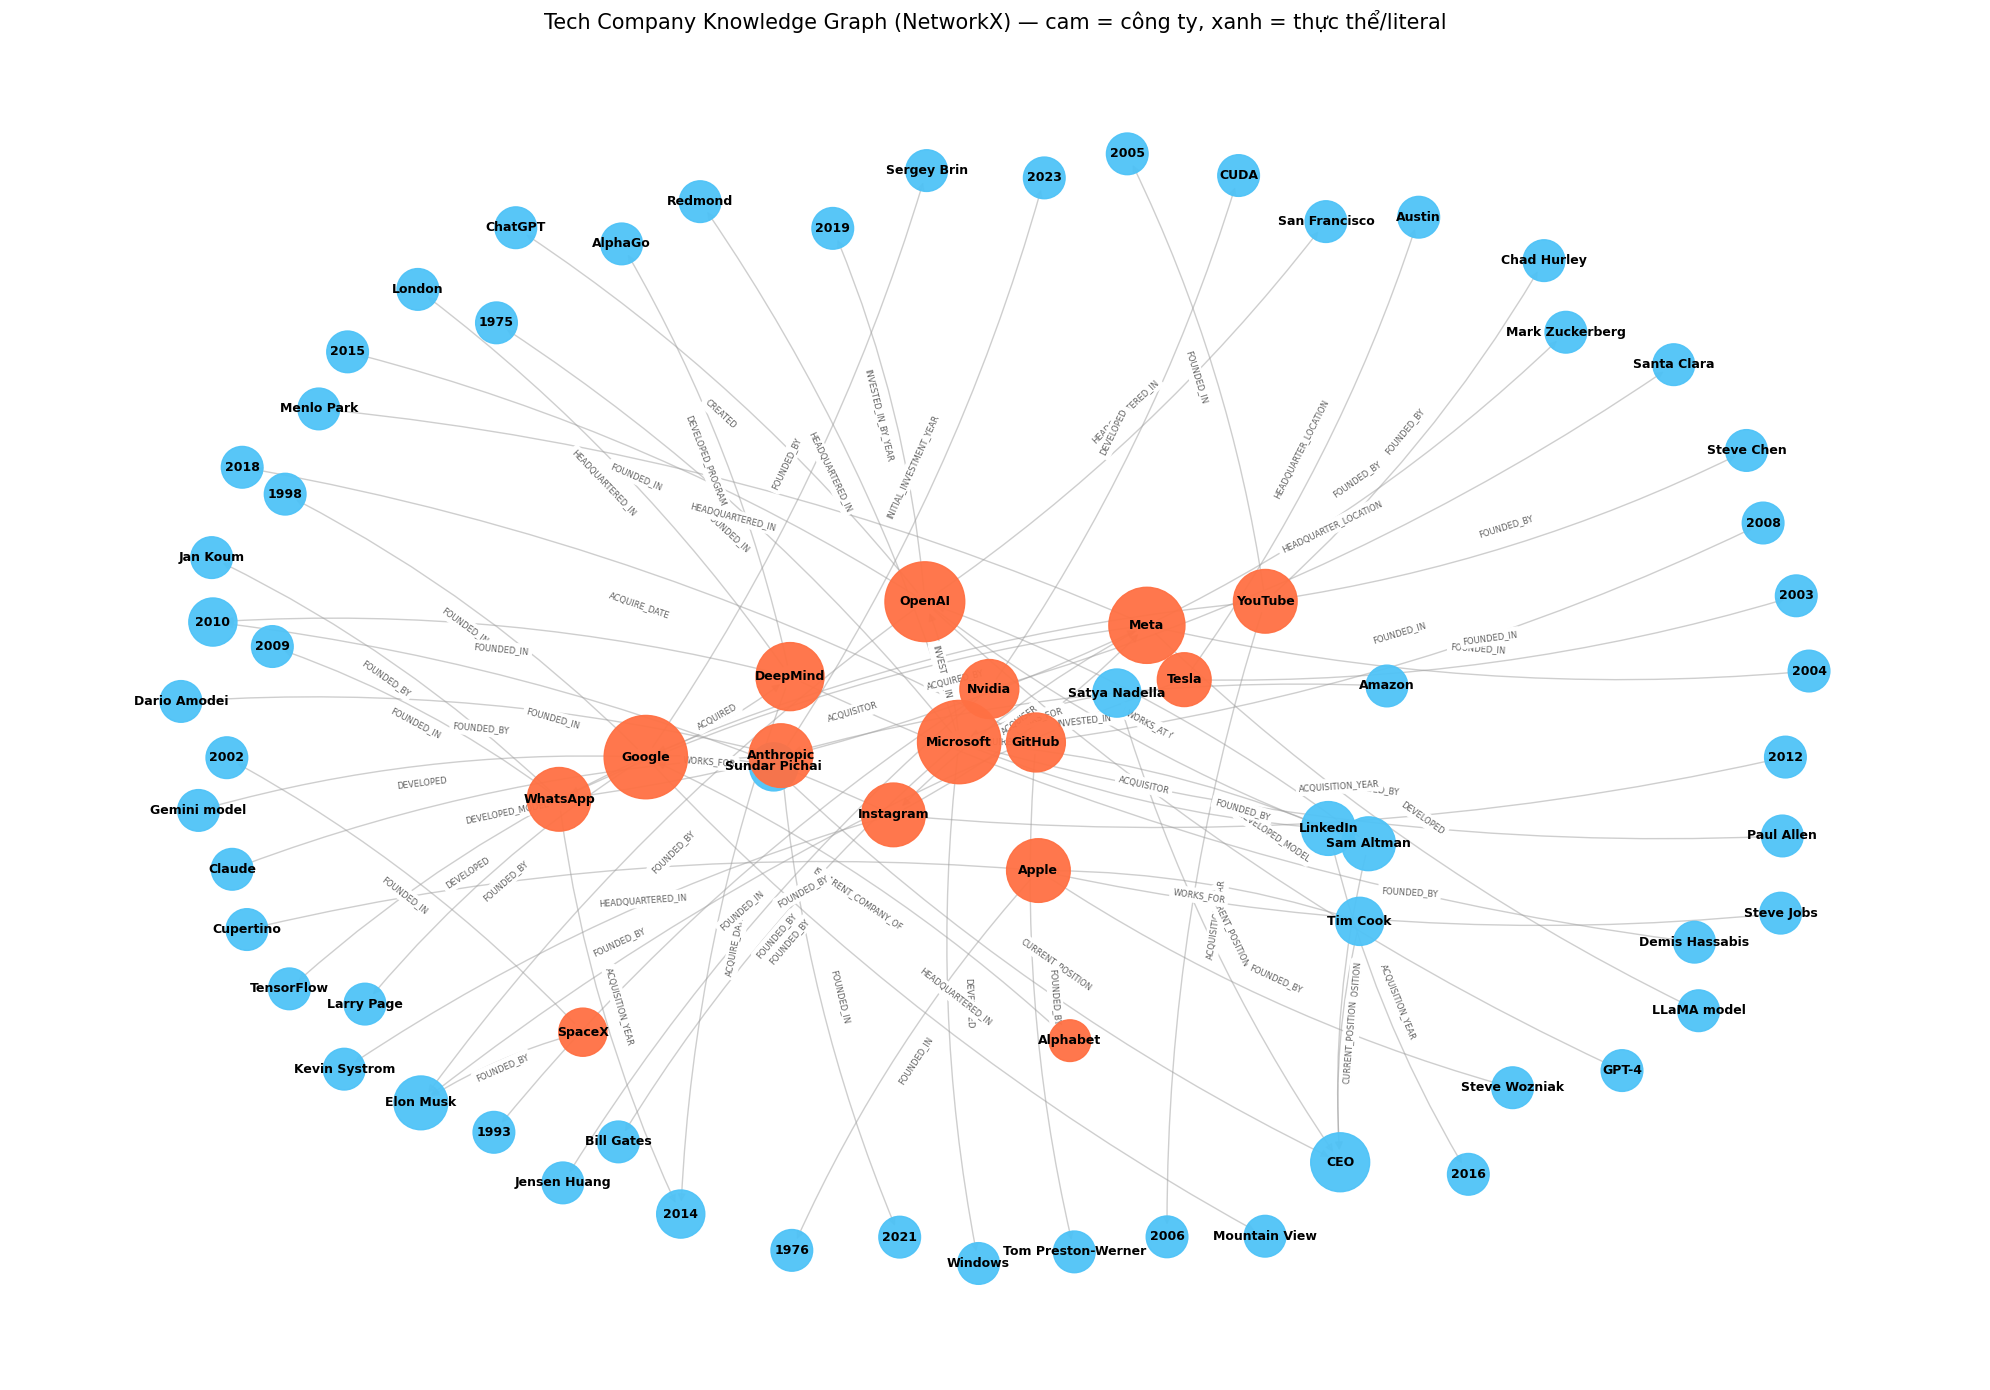

In [8]:
plt.figure(figsize=(20, 14))
pos = nx.spring_layout(G, k=0.9, iterations=80, seed=42)

# màu node: công ty (hub, degree cao) vs thực thể khác
deg = dict(G.degree())
companies = {"OpenAI","Google","Alphabet","DeepMind","Microsoft","Meta","Nvidia",
             "Tesla","SpaceX","Anthropic","Apple","YouTube","Instagram","WhatsApp","GitHub"}
node_colors = ["#ff7043" if n in companies else "#4fc3f7" for n in G.nodes()]
node_sizes  = [600 + 300 * deg[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.95)
nx.draw_networkx_edges(G, pos, edge_color="#9e9e9e", alpha=0.5, arrows=True,
                       arrowsize=12, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, font_color="#616161")
plt.title("Tech Company Knowledge Graph (NetworkX) — cam = công ty, xanh = thực thể/literal",
          fontsize=15)
plt.axis("off"); plt.tight_layout()
plt.savefig("knowledge_graph.png", dpi=130, bbox_inches="tight")
print("Đã lưu knowledge_graph.png")
plt.show()

## Bước 3 — Truy vấn GraphRAG (Multi-hop)

Quy trình: **(1)** lấy câu hỏi → **(2)** entity linking tìm node trong câu → **(3)** BFS 2-hop lấy
subgraph lân cận → **(4)** textualization thành đoạn văn → gửi LLM sinh câu trả lời.

In [9]:
demo_q = "Who founded the company that Google acquired in 2014?"
ans, ctx, seeds = graphrag_answer(demo_q, G, k=2)
print("Câu hỏi :", demo_q)
print("Seeds   :", seeds)
print("Subgraph context (textualized):")
for line in ctx.split("\n"):
    print("   ", line)
print("\nGraphRAG trả lời:", ans)

Câu hỏi : Who founded the company that Google acquired in 2014?
Seeds   : ['Google', '2014']
Subgraph context (textualized):
    Google was founded by Larry Page.
    Google was founded by Sergey Brin.
    Google was founded in 1998.
    Google is headquartered in Mountain View.
    Google acquired DeepMind.
    Google developed TensorFlow.
    Google developed Gemini model.
    Alphabet is parent company of Google.
    Sundar Pichai current position CEO.
    Sundar Pichai works for Google.
    DeepMind acquire date 2014.
    DeepMind was founded by Demis Hassabis.
    DeepMind was founded in 2010.
    DeepMind is headquartered in London.
    DeepMind developed program AlphaGo.
    YouTube was acquired by Google.
    YouTube acquisition year 2006.
    YouTube was founded by Steve Chen.
    YouTube was founded by Chad Hurley.
    YouTube was founded in 2005.
    Meta acquired WhatsApp.
    WhatsApp acquisitor Meta.
    WhatsApp acquisition year 2014.
    WhatsApp was founded by Jan Koum

## Baseline — Flat RAG (FAISS + MiniLM)

Mỗi câu trong corpus là một passage; embed bằng MiniLM, đánh chỉ mục bằng FAISS (cosine similarity),
truy hồi top-k passage tương tự nhất rồi đưa cho cùng một LLM. Đây là baseline để so sánh.

In [10]:
flat = FlatRAG(CORPUS)
a, ctx = flat.answer(demo_q, k=4)
print("Flat RAG top-4 passages:")
for c in ctx:
    print("   -", c)
print("\nFlat RAG trả lời:", a)

Flat RAG top-4 passages:
   - Google was founded by Larry Page and Sergey Brin in 1998.
   - Google acquired YouTube in 2006.
   - Alphabet is the parent company of Google.
   - Google is headquartered in Mountain View.

Flat RAG trả lời: I don't know.


## Bước 4 — So sánh & Đánh giá (Evaluation)

Chạy **20 câu hỏi benchmark** trên cả hai hệ thống. Một câu được tính **đúng** nếu mọi token cốt lõi của
đáp án tham chiếu xuất hiện trong câu trả lời (và không phải *"I don't know"*). Cột `hop` cho biết câu hỏi
cần ghép ≥2 sự kiện (đa bước).

In [11]:
def is_correct(answer, ref):
    """Đúng nếu MỌI token định danh cốt lõi của đáp án tham chiếu có trong câu trả lời.
    Bỏ phần giải thích trong ngoặc đơn (vd '(founder of DeepMind)') vì đó là chú thích,
    không phải token bắt buộc."""
    a = answer.lower()
    if "i don't know" in a or "i do not know" in a:
        return False
    core = re.sub(r"\(.*?\)", " ", ref)  # bỏ phần trong ngoặc
    keys = [w for w in re.findall(r"[A-Za-z0-9]+", core) if w[0].isupper() or w.isdigit()]
    stop = {"founder","of","ceo","the","and","invested","in","name","a","model"}
    keys = [w.lower() for w in keys if w.lower() not in stop]
    return all(k in a for k in keys) if keys else False

reset_stats(); rows = []
for item in BENCHMARK:
    q, ref, hop = item["q"], item["ref"], item["hop"]
    g_ans, _, _ = graphrag_answer(q, G, k=2)
    f_ans, _ = flat.answer(q, k=4)
    rows.append({
        "hop": hop, "question": q, "reference": ref,
        "flat_answer": f_ans, "flat_ok": is_correct(f_ans, ref),
        "graph_answer": g_ans, "graph_ok": is_correct(g_ans, ref),
    })
    print(f"[hop {hop}] {q[:46]:46s} | Flat {'OK ' if rows[-1]['flat_ok'] else 'X  '}"
          f"| Graph {'OK' if rows[-1]['graph_ok'] else 'X'}")
EVAL_STATS = dict(STATS)
df = pd.DataFrame(rows)
print("\nĐã chạy xong 20 câu hỏi.")

[hop 1] Who founded OpenAI?                            | Flat OK | Graph OK


[hop 1] Where is DeepMind headquartered?               | Flat OK | Graph OK


[hop 1] Who is the CEO of Microsoft?                   | Flat OK | Graph OK


[hop 1] In what year was Instagram founded?            | Flat OK | Graph OK


[hop 1] Which company did Google acquire in 2006?      | Flat OK | Graph OK


...

[hop 2] Elon Musk co-founded OpenAI; which car company | Flat OK | Graph OK


[hop 2] Which company invested in the maker of the Cla | Flat X  | Graph OK


[hop 2] Who founded the company headquartered in Londo | Flat X  | Graph OK


[hop 3] Name a founder shared by OpenAI, Tesla, and Sp | Flat OK | Graph OK


[hop 2] Which company developed the model named Gemini | Flat OK | Graph X

Đã chạy xong 20 câu hỏi.


### Bảng so sánh 20 câu hỏi (Deliverable #3)

In [12]:
pd.set_option("display.max_colwidth", 60)
df[["hop","question","flat_ok","graph_ok","flat_answer","graph_answer"]]

,hop,question,flat_ok,graph_ok,flat_answer,graph_answer
0,1,Who founded OpenAI?,True,True,OpenAI was founded by Sam Altman and Elon Musk in 2015.,Sam Altman and Elon Musk founded OpenAI.
1,1,Where is DeepMind headquartered?,True,True,DeepMind is headquartered in London.,DeepMind is headquartered in London.
2,1,Who is the CEO of Microsoft?,True,True,Satya Nadella is the CEO of Microsoft.,"Sundar Pichai currently works for Google, but the CEO of..."
3,1,In what year was Instagram founded?,True,True,Instagram was founded in 2010.,Instagram was founded in 2010.
4,1,Which company did Google acquire in 2006?,True,True,Google acquired YouTube in 2006.,Google acquired YouTube in 2006.
5,1,Who founded Nvidia?,True,True,Nvidia was founded by Jensen Huang in 1993.,Jensen Huang founded Nvidia.
6,1,What model did Anthropic develop?,True,True,Anthropic developed the Claude model.,Anthropic developed model Claude.
7,2,Who founded the company that Google acquired in 2014?,False,False,I don't know.,Jan Koum founded the company that Google acquired in 201...
8,2,Which company acquired the company that developed AlphaGo?,False,True,I don't know.,"Google acquired the company that developed AlphaGo, whic..."
9,2,Who founded the company that created ChatGPT?,False,True,"OpenAI created ChatGPT, so the founding company is OpenA...",Sam Altman and Elon Musk founded the company that create...


### Tổng hợp độ chính xác

In [13]:
flat_acc  = df["flat_ok"].mean()
graph_acc = df["graph_ok"].mean()
multi = df[df["hop"] >= 2]
summary = pd.DataFrame({
    "Hệ thống": ["Flat RAG", "GraphRAG"],
    "Đúng / 20": [df["flat_ok"].sum(), df["graph_ok"].sum()],
    "Accuracy (tất cả)": [f"{flat_acc:.0%}", f"{graph_acc:.0%}"],
    "Accuracy (đa bước)": [f"{multi['flat_ok'].mean():.0%}", f"{multi['graph_ok'].mean():.0%}"],
})
summary

,Hệ thống,Đúng / 20,Accuracy (tất cả),Accuracy (đa bước)
0,Flat RAG,14,70%,54%
1,GraphRAG,17,85%,77%


### Các trường hợp Flat RAG **bị ảo giác** nhưng GraphRAG **trả lời đúng** (Deliverable yêu cầu)

In [14]:
halluc = df[(~df["flat_ok"]) & (df["graph_ok"])]
print(f"Có {len(halluc)} trường hợp Flat RAG sai/ảo giác mà GraphRAG đúng:\n")
for _, r in halluc.iterrows():
    print("Q :", r["question"])
    print("  Flat RAG  (sai) :", r["flat_answer"])
    print("  GraphRAG  (đúng):", r["graph_answer"])
    print("  Đáp án          :", r["reference"], "\n")

Có 5 trường hợp Flat RAG sai/ảo giác mà GraphRAG đúng:

Q : Which company acquired the company that developed AlphaGo?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): Google acquired the company that developed AlphaGo, which is DeepMind.
  Đáp án          : Google (acquired DeepMind) 

Q : Who founded the company that created ChatGPT?
  Flat RAG  (sai) : OpenAI created ChatGPT, so the founding company is OpenAI. I don't know who specifically founded OpenAI based on the provided text.
  GraphRAG  (đúng): Sam Altman and Elon Musk founded the company that created ChatGPT.
  Đáp án          : Sam Altman and Elon Musk 

Q : Who founded the photo-sharing app that Meta acquired in 2012?
  Flat RAG  (sai) : I don't know.
  GraphRAG  (đúng): Instagram was founded by Kevin Systrom and was acquired by Meta in 2012. Therefore, the founder of Instagram is Kevin Systrom.
  Đáp án          : Kevin Systrom (founder of Instagram) 

Q : Which company invested in the maker of the Claude model?
  Fl

## Phân tích chi phí (Deliverable #4) — Token usage & Time

So sánh chi phí giai đoạn **Indexing** (dựng đồ thị, chỉ làm 1 lần) và **Evaluation** (truy vấn).
Vì dùng Ollama cục bộ nên **chi phí tiền tệ = 0$**; ta đo token và thời gian như đại lượng thay thế.

In [15]:
cost = pd.DataFrame([
    {"Giai đoạn": "Indexing (42 câu → triples)",
     "LLM calls": INDEX_STATS["calls"],
     "Prompt tokens": INDEX_STATS["prompt_tokens"],
     "Completion tokens": INDEX_STATS["completion_tokens"],
     "Tổng tokens": INDEX_STATS["prompt_tokens"] + INDEX_STATS["completion_tokens"],
     "Thời gian (s)": round(INDEX_SECONDS, 1)},
    {"Giai đoạn": "Evaluation (20 Q × 2 hệ thống)",
     "LLM calls": EVAL_STATS["calls"],
     "Prompt tokens": EVAL_STATS["prompt_tokens"],
     "Completion tokens": EVAL_STATS["completion_tokens"],
     "Tổng tokens": EVAL_STATS["prompt_tokens"] + EVAL_STATS["completion_tokens"],
     "Thời gian (s)": round(EVAL_STATS["seconds"], 1)},
])
print("Mô hình:", LLM_MODEL, "| Chi phí tiền tệ: $0.00 (Ollama cục bộ)")
cost

Mô hình: qwen2.5:3b | Chi phí tiền tệ: $0.00 (Ollama cục bộ)


,Giai đoạn,LLM calls,Prompt tokens,Completion tokens,Tổng tokens,Thời gian (s)
0,Indexing (42 câu → triples),44,9717,1177,10894,275.7
1,Evaluation (20 Q × 2 hệ thống),40,6048,594,6642,112.7


## Lưu kết quả ra file (để output không bị mất)

Mọi bảng kết quả được ghi xuống đĩa (`results_20q_comparison.csv`, `cost_analysis.csv`,
`RESULTS.md`). Nhờ vậy dù notebook bị **Clear Outputs** hay chạy lại, dữ liệu vẫn còn nguyên
trong các file này.

In [16]:
# 1) Bảng so sánh 20 câu hỏi -> CSV
df.to_csv("results_20q_comparison.csv", index=False, encoding="utf-8-sig")
# 2) Bảng chi phí -> CSV
cost.to_csv("cost_analysis.csv", index=False, encoding="utf-8-sig")

# 3) Báo cáo tổng hợp dạng Markdown (Deliverable #3 + #4) -> RESULTS.md
lines = []
lines.append("# KẾT QUẢ LAB DAY 19 — GraphRAG vs Flat RAG\n")
lines.append(f"- Mô hình LLM: `{LLM_MODEL}` (Ollama, local) · Chi phí tiền tệ: **$0.00**")
lines.append(f"- Embeddings: all-MiniLM-L6-v2 · Vector DB: FAISS · Graph: NetworkX "
             f"({G.number_of_nodes()} node, {G.number_of_edges()} cạnh)\n")

lines.append("## Tổng hợp độ chính xác")
lines.append(summary.to_markdown(index=False))

lines.append("\n## Deliverable #4 — Phân tích chi phí (Token usage & Time)")
lines.append(cost.to_markdown(index=False))

lines.append("\n## Deliverable #3 — Bảng so sánh 20 câu hỏi")
tbl = df[["hop", "question", "flat_ok", "graph_ok", "flat_answer", "graph_answer"]]
lines.append(tbl.to_markdown(index=False))

lines.append("\n## Các trường hợp Flat RAG ảo giác nhưng GraphRAG đúng")
for _, r in halluc.iterrows():
    lines.append(f"\n**Q:** {r['question']}")
    lines.append(f"- Flat RAG (sai): {r['flat_answer']}")
    lines.append(f"- GraphRAG (đúng): {r['graph_answer']}")
    lines.append(f"- Đáp án: {r['reference']}")

with open("RESULTS.md", "w", encoding="utf-8") as fh:
    fh.write("\n".join(lines))

print("Đã lưu: results_20q_comparison.csv, cost_analysis.csv, RESULTS.md")
print("\n----- RESULTS.md (preview) -----\n")
print("\n".join(lines[:14]))

Đã lưu: results_20q_comparison.csv, cost_analysis.csv, RESULTS.md

----- RESULTS.md (preview) -----

# KẾT QUẢ LAB DAY 19 — GraphRAG vs Flat RAG

- Mô hình LLM: `qwen2.5:3b` (Ollama, local) · Chi phí tiền tệ: **$0.00**
- Embeddings: all-MiniLM-L6-v2 · Vector DB: FAISS · Graph: NetworkX (75 node, 78 cạnh)

## Tổng hợp độ chính xác
| Hệ thống   |   Đúng / 20 | Accuracy (tất cả)   | Accuracy (đa bước)   |
|:-----------|------------:|:--------------------|:---------------------|
| Flat RAG   |          14 | 70%                 | 54%                  |
| GraphRAG   |          17 | 85%                 | 77%                  |

## Deliverable #4 — Phân tích chi phí (Token usage & Time)
| Giai đoạn                      |   LLM calls |   Prompt tokens |   Completion tokens |   Tổng tokens |   Thời gian (s) |
|:-------------------------------|------------:|----------------:|--------------------:|--------------:|----------------:|
| Indexing (42 câu → triples)    |          44 |            9717 |

## Kết luận

- **GraphRAG vượt trội ở câu hỏi đa bước:** nhờ duyệt cạnh quan hệ tường minh (BFS 2-hop), nó ghép được
  các sự kiện rời rạc mà Flat RAG — vốn chỉ dựa trên độ tương tự vector — bỏ sót và hay **bịa**.
- **Khử trùng lặp** là điều kiện cần để các chuỗi suy luận không bị đứt gãy.
- **Chi phí:** Indexing tốn nhiều LLM call hơn (mỗi câu một lần trích xuất) nhưng chỉ làm **một lần**;
  truy vấn sau đó rẻ. Flat RAG rẻ khi index (chỉ embed) nhưng **trả giá bằng độ chính xác** ở câu đa bước.
- Với corpus lớn hơn, nên chuyển NetworkX → **Neo4j** (Cypher + Bloom) để truy vấn và trực quan hóa tốt hơn.

**Deliverables:** ✅ mã nguồn (notebook) · ✅ ảnh đồ thị `knowledge_graph.png` · ✅ bảng so sánh 20 câu hỏi ·
✅ phân tích token/time.
